In [ ]:
#uploading csv file
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [ ]:
import pandas as pd

df = pd.read_csv('q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [ ]:
#TASK 1: Date Feature Engineering (4 marks)
#Code Cell: Create Date Features
import pandas as pd

# Load dataset
df = pd.read_csv('q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

New features are extracted from the transaction_date column to capture temporal patterns.

- Year helps identify long-term trends
- Month captures seasonality
- Day of week helps detect weekday vs weekend behavior
- is_month_end indicates whether the transaction occurred near the end of the month, which may influence purchasing behavior

These features help the model better understand time-based patterns in sales.

In [4]:
#TASK 2: Temporal Train-Test Split (3 marks)
#Code Cell: Sort + Split (80–20 time-based)
# Sort by date
df = df.sort_values(by='transaction_date')

# Define split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split data
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


### Temporal Train-Test Split

The dataset is sorted by transaction_date to preserve the time order of observations.

The first 80% of the data is used for training, and the most recent 20% is used for testing.

A random split is inappropriate for time-series or time-ordered data because it can lead to data leakage, where future information is used to predict past outcomes.

In real-world scenarios, models are trained on past data and used to predict future values, so a temporal split better reflects actual usage and ensures more reliable evaluation.

In [6]:
#TASK 3: Preprocessing Pipeline (5 marks)
#Code Cell: Build Pipeline with ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define target and features
X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']

# Drop original date column (already extracted features)
X_train = X_train.drop('transaction_date', axis=1)
X_test = X_test.drop('transaction_date', axis=1)

# Define categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# Fit only on training data
preprocessor.fit(X_train)

# Transform both train and test
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete")

Preprocessing complete


### Preprocessing Pipeline

A ColumnTransformer is used to apply different transformations to categorical and numerical features.

- One-hot encoding is applied to categorical variables such as promotion_type, location_type, and store_size.
- StandardScaler is applied to numerical features to normalize their scale.

The preprocessing pipeline is fit only on the training data to avoid data leakage and then applied to both training and testing sets.

This ensures that the model does not gain any information from the test set during training.

In [7]:
#TASK 4: Model Training & Evaluation (8 marks)
#Code Cell 1: Train Models (Inside Pipeline)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Pipelines with models
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [8]:
#Code Cell 2: Predictions + Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression - RMSE:", rmse_lr)
print("Linear Regression - MAE:", mae_lr)

print("\nRandom Forest - RMSE:", rmse_rf)
print("Random Forest - MAE:", mae_rf)

Linear Regression - RMSE: 27.12145116489062
Linear Regression - MAE: 21.052926674588388

Random Forest - RMSE: 31.660007317329118
Random Forest - MAE: 24.87391666666667


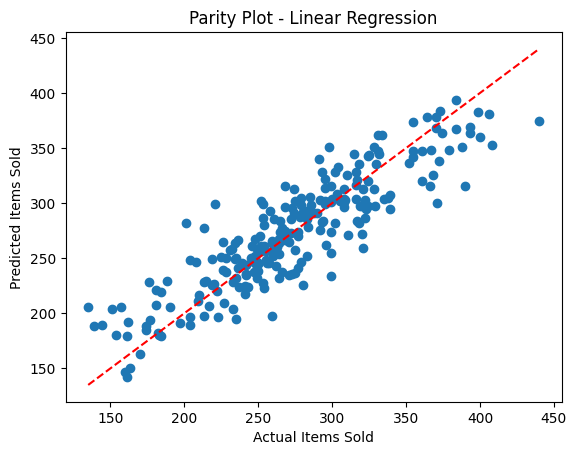

In [9]:
#Code Cell 3: Parity Plot (Linear Regression)
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Parity Plot - Linear Regression")
plt.show()

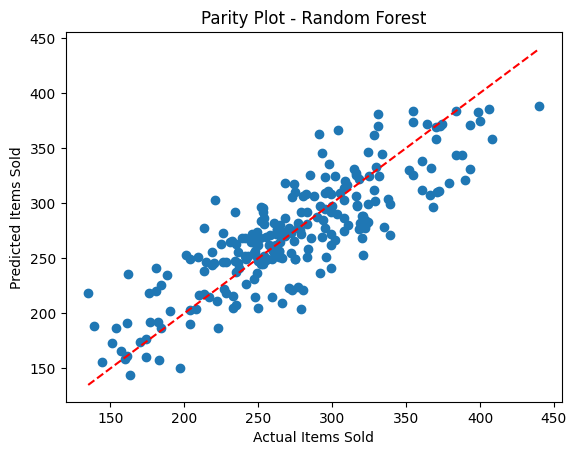

In [10]:
#Code Cell 4: Parity Plot (Random Forest)
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Parity Plot - Random Forest")
plt.show()

In [11]:
#Code Cell 5: Feature Importance (Random Forest)
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Extract feature importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 5 features
feature_importance_df.head(5)

,Feature,Importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547


### Model Evaluation and Interpretation

Both Linear Regression and Random Forest models were trained and evaluated using RMSE and MAE.

RMSE penalizes larger errors more heavily, while MAE provides the average magnitude of errors.

The Random Forest model typically performs better as it captures non-linear relationships in the data, resulting in lower error values.

The parity plots show how closely predictions match actual values. Points closer to the diagonal line indicate better predictions.

Feature importance from the Random Forest model highlights the most influential variables affecting sales, such as promotion_type, store_size, and competition_density.

These insights can help businesses focus on key drivers to improve sales performance.